# Movie Rating Prediction Model - Summary Assignment Part 2

**Course:** Machine Learning

**Submitted by:**
זוהר קולפ - 322435918
רוני פחימה - 212009260

**Project Goal:** Build a model that predicts a movie's average rating (averageRating) before its release, using only information available at production time.

**GitHub Repository:** [movie-rating-prediction](https://github.com/ZoeyKulp/movie-rating-prediction)

## Library Imports

In [1]:
!pip install shap

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast, re, os
import shap                                             
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, GridSearchCV, cross_validate, cross_val_predict
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance   
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  
from statsmodels.stats.outliers_influence import variance_inflation_factor
from collections import Counter                         
import joblib                                          

RANDOM_STATE = 42

## Data Loading & Exploratory Data Analysis (EDA)

Initial exploration of the dataset: structure, missing values, outliers, and format validation.

In [3]:
df = pd.read_csv("dataset.csv", low_memory=False)
df.sample(5)

,tconst,primaryTitle,startYear,genres,lead_actors_ids,runtimeMinutes,averageRating,Language,Country,numVotes,budget,BoxOffice,plot
110530,tt8726180,Cave Rescue,2019.0,"['Action', 'Adventure', 'Drama']","['nm9021327', 'nm0810653', 'nm1975399', 'nm547...",99.0,5.8,NaN,NaN,1543.0,NaN,NaN,NaN
117117,tt0110762,Father and Son,1994.0,['Drama'],"['nm0686375', 'nm0227958', 'nm0649843', 'nm041...",95.0,6.7,Italian,NaN,47.0,NaN,NaN,Father and Son (Italian: Padre e figlio) is a ...
115148,tt8706874,DZIDZIO First Time,2018.0,Comedy,"[""nm8912868"", ""nm9369973"", ""nm7223781"", ""nm102...",100.0,6.3,NaN,NaN,335.0,NaN,NaN,NaN
50924,tt5673766,Raja Cheyyi Vesthe,2016.0,"['Action', 'Romance']","['nm5624098', 'nm10641095', 'nm4015380', 'nm73...",144.0,5.4,Telugu,India,92.0,NaN,NaN,Raja Ram (Nara Rohit) is an aspiring filmmaker...
50286,tt10907844,Running to the Sky,2019.0,['Drama'],"['nm10955467', 'nm10955468', 'nm8898252', 'nm5...",88.0,6.4,Kyrgyz,Kyrgyzstan,90.0,NaN,NaN,A schoolboy gets a chance of bigger opportunit...


In [4]:
print(df.shape)
print(df.dtypes)

(133884, 13)
tconst              object
primaryTitle        object
startYear          float64
genres              object
lead_actors_ids     object
runtimeMinutes     float64
averageRating      float64
Language            object
Country             object
numVotes           float64
budget              object
BoxOffice          float64
plot                object
dtype: object


In [5]:
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percent': (df.isna().mean() * 100)
})
missing_summary.sort_values('Missing Percent', ascending=False)

,Missing Count,Missing Percent
budget,117334,87.638553
BoxOffice,115968,86.618267
Country,80203,59.904843
Language,78162,58.380389
plot,74215,55.432315
averageRating,18324,13.686475
lead_actors_ids,10030,7.491560
numVotes,9122,6.813361
genres,2573,1.921813
tconst,0,0.000000


### Data Validation & Sanity Checks

Checking actor column formats, duplicates, rating ranges, release years, runtime values, genre formats, country name variations, and special NULL values.

In [6]:
def classify_actors(x):
    if pd.isna(x):
        return 'NaN אמיתי'
    x_str = str(x).strip()
    if x_str in ['', '[]', 'nan', '\\N', 'Not Found']:
        return 'רשימה ריקה []'
    try:
        lst = ast.literal_eval(x_str)
        if isinstance(lst, list):
            if len(lst) == 0:
                return 'רשימה ריקה []'
            if any(str(i).strip().startswith('nm') for i in lst):
                return 'IDs תקינים (nm)'
            return 'שמות שחקנים'
    except:
        pass
    if 'nm' in x_str:
        return 'IDs תקינים (nm)'
    return 'שמות שחקנים'

counts = df['lead_actors_ids'].apply(classify_actors).value_counts()
total = len(df)

summary = pd.DataFrame({
    'Count': counts,
    'Percent': (counts / total * 100).round(6)
})

summary.index.name = None
summary.columns.name = 'lead_actors_ids'

display(summary)

lead_actors_ids,Count,Percent
IDs תקינים (nm),114981,85.881061
NaN אמיתי,10030,7.491560
רשימה ריקה [],4731,3.533656
שמות שחקנים,4142,3.093723


In [7]:
print('Duplicated rows:', df.duplicated().sum())
print('Duplicated tconst:', df['tconst'].duplicated().sum())

Duplicated rows: 0
Duplicated tconst: 0


In [8]:
print("Minimum rating:", df["averageRating"].min())
print("Maximum rating:", df["averageRating"].max())

Minimum rating: 1.0
Maximum rating: 10.0


In [9]:
print('Min year:', df['startYear'].min())
print('Max year:', df['startYear'].max())
df[(df['startYear'] < 1888) | (df['startYear'] > 2026)][['primaryTitle', 'startYear']]

Min year: 0.0
Max year: 2026.0


,primaryTitle,startYear
64465,Alien Wars: Judgement Day,0.0
64533,Alhambra Decree 1492,0.0
64627,Action Not Words,0.0
64687,Alam High School,0.0
64828,All That Ends,0.0
...,...,...
71658,Agent Surya,0.0
71761,All That's Left,0.0
71816,Aleya's Tango: Dreams of a Vampyre,0.0
71855,Almost Blue,0.0


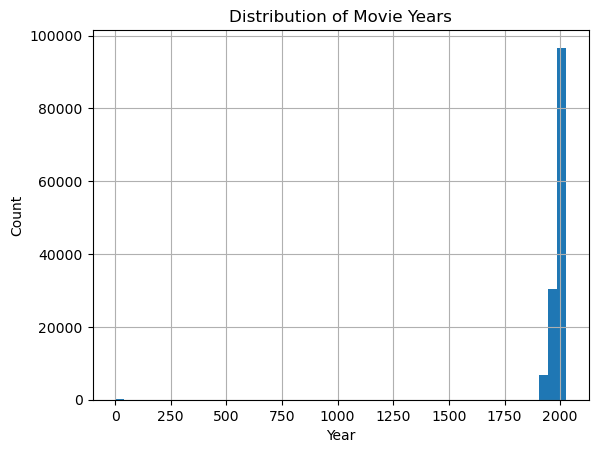

In [10]:
df['startYear'].hist(bins=50)
plt.xlabel('Year')
plt.ylabel('Count')
plt.title('Distribution of Movie Years')
plt.show()

=== averageRating ===
count    115560.00
mean          6.07
std           1.29
min           1.00
25%           5.30
50%           6.20
75%           7.00
max          10.00
Name: averageRating, dtype: float64

סרטים עם דירוג:  115,560
סרטים ללא דירוג: 18,324


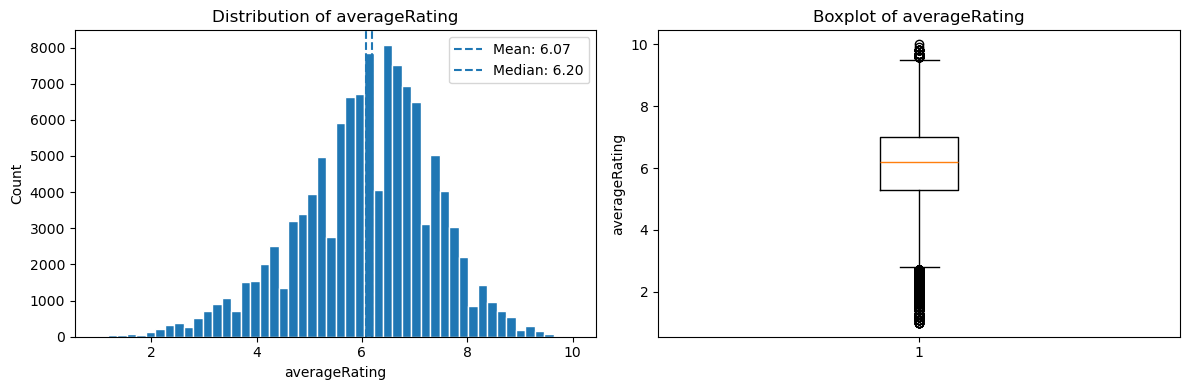

In [11]:
rating = df['averageRating'].dropna()

print('=== averageRating ===')
print(rating.describe().round(2))
print(f'\nסרטים עם דירוג:  {df["averageRating"].notna().sum():,}')
print(f'סרטים ללא דירוג: {df["averageRating"].isna().sum():,}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rating, bins=50, edgecolor='white')
axes[0].axvline(rating.mean(),   linestyle='--', label=f'Mean: {rating.mean():.2f}')
axes[0].axvline(rating.median(), linestyle='--', label=f'Median: {rating.median():.2f}')
axes[0].set_title('Distribution of averageRating')
axes[0].set_xlabel('averageRating')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].boxplot(rating, vert=True)
axes[1].set_title('Boxplot of averageRating')
axes[1].set_ylabel('averageRating')

plt.tight_layout()
plt.show()


In [12]:
print("Minimum runtime:", df["runtimeMinutes"].min())
print("Maximum runtime:", df["runtimeMinutes"].max())

Minimum runtime: 60.0
Maximum runtime: 300.0


In [13]:
has_brackets = df['genres'].str.startswith('[', na=False).sum()
no_brackets  = (~df['genres'].str.startswith('[', na=True) & df['genres'].notna()).sum()
print(f'עם סוגריים:  {has_brackets:,}')
print(f'ללא סוגריים: {no_brackets:,}')

עם סוגריים:  65,022
ללא סוגריים: 66,289


In [14]:
genre_patterns = []

for value in df[df['genres'].notna()]['genres']:
    
    genre_patterns.append(str(value))

# DataFrame של כל הביטויים
genre_patterns_df = pd.DataFrame({
    'genre_pattern': genre_patterns
})

# שכיחות הביטויים
genre_patterns_stats = (
    genre_patterns_df['genre_pattern']
    .value_counts()
    .reset_index()
)

genre_patterns_stats.columns = ['genre_pattern', 'count']

print(genre_patterns_stats)

                       genre_pattern  count
0                              Drama  10822
1                          ['Drama']  10224
2                        Documentary   6074
3                    ['Documentary']   5542
4                             Comedy   5338
...                              ...    ...
2220  ["Action", "Comedy", "Sci-Fi"]      1
2221          Mystery,Romance,Sci-Fi      1
2222         Animation,Drama,Musical      1
2223        Comedy,Documentary,Sport      1
2224              Action,Adult,Drama      1

[2225 rows x 2 columns]


In [15]:
# בדיקת וריאציות של USA
countries = df['Country'].dropna().unique()

terms_to_check = ['USA', 'U.S.A', 'U.S.', 'United States', 'United States of America']

for term in terms_to_check:
    matches = [c for c in countries if term.lower() in str(c).lower()]
    print(f'\n===== {term} =====')
    print(f'Total matches: {len(matches)}')
    print(matches[:10])


===== USA =====
Total matches: 9
['USA', "['USA', 'Canada']", "['USA', 'Spain']", 'USA / Australia', 'USA Canada', 'Switzerland, USA', 'UK (1966 version), USA (2012 version)', 'Argentina, USA', 'India, USA']

===== U.S.A =====
Total matches: 0
[]

===== U.S. =====
Total matches: 5
['U.S.', 'North East, Maryland, U.S.', 'Las Vegas, Nevada, U.S.', 'U.S., Canada (2013), Spain, Italy, France, Germany, New Zealand, Australia (2015)', 'Canada, U.S.']

===== United States =====
Total matches: 806
['United Kingdom United States', 'United States', 'United States Japan', 'Australia United States', 'United States Canada', 'United States [ 3 ]', 'United States [ 1 ] Germany [ 1 ]', 'United States [ 1 ] Canada [ 1 ] Germany [ 1 ]', 'United States [ 1 ] [ 2 ]', 'United States [ 1 ]']

===== United States of America =====
Total matches: 1
['United States of America']


In [16]:
# בדיקת ערכי NULL מיוחדים ותווים חשודים
special_values = [
    "\\N",
    "N/A",
    "NA",
    "NULL",
    "###",
    "@@@",
    "[citation needed]",
    "<br"
]

for value in special_values:
    
    print(f"\n===== Checking: {value} =====")
    
    found = False
    
    for col in df.columns:
        
        count = df[col].astype(str).str.contains(
            value,
            regex=False,
            na=False
        ).sum()
        
        if count > 0:
            
            found = True
            
            print(f"{col}: {count}")
    
    if not found:
        print("No matches found")


# בדיקת סוגריים חשודים בעמודת Country
country_patterns = ["[", "]"]

for pattern in country_patterns:
    
    count = df["Country"].astype(str).str.contains(
        pattern,
        regex=False,
        na=False
    ).sum()
    
    print(f"\n===== Checking Country for: {pattern} =====")
    print(f"Country: {count}")


===== Checking: \N =====
genres: 102

===== Checking: N/A =====
plot: 1

===== Checking: NA =====
primaryTitle: 14
plot: 269

===== Checking: NULL =====
No matches found

===== Checking: ### =====
No matches found

===== Checking: @@@ =====
No matches found

===== Checking: [citation needed] =====
Country: 1
plot: 233

===== Checking: <br =====
Country: 1

===== Checking Country for: [ =====
Country: 647

===== Checking Country for: ] =====
Country: 645


## 3.1 prepare_data Function

The function receives a raw DataFrame and returns a processed DataFrame with only the relevant features.
The function is deterministic, fully independent, and runs without errors on both a single row and the full dataset.

**Processing steps:** Clean bad values → Numeric conversions → Parse genres → Binary genre features → Complex numeric features → is_english, is_us → Select 16 final columns.

In [17]:
BAD_VALUES = ["\\N", "N/A", "NA", "NULL", "###", "@@@", "[citation needed]", "Not Found", ""]
TOP_GENRES = ["Drama", "Comedy", "Action", "Thriller", "Romance", "Horror", "Documentary", "Crime", "Adventure", "Animation"]

def prepare_data(df):
    df = df.copy()

    # שלב 1: ניקוי bad values
    for col in df.columns:
        df[col] = df[col].replace(BAD_VALUES, np.nan)

    # שלב 2: המרות נומריות
    df["startYear"] = pd.to_numeric(df["startYear"], errors="coerce")
    df.loc[df["startYear"] == 0,   "startYear"] = np.nan
    df.loc[df["startYear"] < 1888, "startYear"] = np.nan
    df.loc[df["startYear"] > 2026, "startYear"] = np.nan
    df["runtimeMinutes"] = pd.to_numeric(df["runtimeMinutes"], errors="coerce")

    # שלב 3: פרסור ז'אנרים
    def parse_genres(x):
        if pd.isna(x):
            return []
        x_str = str(x).strip()
        if x_str in ["", "[]", "nan"]:
            return []
        try:
            result = ast.literal_eval(x_str)
            if isinstance(result, list):
                return [str(g).strip() for g in result if str(g).strip()]
        except:
            pass
        x_str = (
            x_str
            .replace("[", "").replace("]", "")
            .replace("'", "").replace('"', "")
        )
        return [g.strip() for g in x_str.split(",") if g.strip()]

    df["genres_list"] = df["genres"].apply(parse_genres)

    # שלב 4: פיצ'רים בינאריים לפי ז'אנר
    for genre in TOP_GENRES:
        col_name = f'is_{genre.lower().replace("-", "_")}'
        df[col_name] = df["genres_list"].apply(
            lambda x, g=genre: 1 if g in x else 0
        )

    # שלב 5: num_genres ו-runtime_per_genre
    df["num_genres"] = df["genres_list"].apply(len)
    df["runtime_per_genre"] = df.apply(
        lambda row: row["runtimeMinutes"] / row["num_genres"]
        if row["num_genres"] > 0 and pd.notna(row["runtimeMinutes"])
        else np.nan,
        axis=1
    )

    # שלב 6: is_english
    def get_is_english(x):
        if pd.isna(x):
            return np.nan
        x_str = str(x).strip()
        if not x_str or x_str.lower() == "nan":
            return np.nan
        return 1 if "english" in x_str.lower() else 0

    df["is_english"] = df["Language"].apply(get_is_english)

    # שלב 7: is_us
    def get_is_usa(x):
        if pd.isna(x):
            return np.nan
        x_str = str(x).strip()
        if not x_str or x_str.lower() == "nan":
            return np.nan
        x_str = x_str.replace("<br/>", " ").replace("<br", " ")
        x_str = x_str.replace("'", "").replace('"', "").replace("[", "").replace("]", "")
        x_str = re.sub(r'\b\d+\b', ' ', x_str)
        x_lower = " ".join(x_str.split()).lower()
        usa_terms = ["united states", "united states of america", "usa", "u.s.", "u.s.a"]
        return 1 if any(term in x_lower for term in usa_terms) else 0

    df["is_us"] = df["Country"].apply(get_is_usa)

    # שלב 8: בחירת עמודות סופיות
    selected_cols = [
        "startYear", "runtimeMinutes", "num_genres", "runtime_per_genre",
        "is_drama", "is_comedy", "is_action", "is_thriller", "is_romance",
        "is_horror", "is_documentary", "is_crime", "is_adventure", "is_animation",
        "is_english", "is_us",
    ]

    # safety
    for col in selected_cols:
        if col not in df.columns:
            df[col] = np.nan

    # Leakage guard
    LEAKAGE_COLS = ['averageRating', 'numVotes', 'BoxOffice']
    leakage_found = [col for col in LEAKAGE_COLS if col in selected_cols]
    assert len(leakage_found) == 0, f"Leakage columns detected: {leakage_found}"

    return df[selected_cols]

In [18]:
X = prepare_data(df)  # df גולמי
y = df.loc[X.index, "averageRating"]
y = y[y.notna()]
X = X.loc[y.index]

print(f"X shape: {X.shape} | y shape: {y.shape} | NaN in y: {y.isna().sum()}")
print(f"\nחסרים:\n{X.isnull().sum()}")
display(X.sample(5))

X shape: (115560, 16) | y shape: (115560,) | NaN in y: 0

חסרים:
startYear                1
runtimeMinutes           0
num_genres               0
runtime_per_genre     1312
is_drama                 0
is_comedy                0
is_action                0
is_thriller              0
is_romance               0
is_horror                0
is_documentary           0
is_crime                 0
is_adventure             0
is_animation             0
is_english           63155
is_us                65085
dtype: int64


,startYear,runtimeMinutes,num_genres,runtime_per_genre,is_drama,is_comedy,is_action,is_thriller,is_romance,is_horror,is_documentary,is_crime,is_adventure,is_animation,is_english,is_us
88180,2010.0,94.0,1,94.0,0,0,0,0,0,1,0,0,0,0,NaN,NaN
25233,1946.0,75.0,3,25.0,0,1,0,0,0,0,0,0,1,1,1.0,1.0
116664,1972.0,78.0,1,78.0,0,1,0,0,0,0,0,0,0,0,0.0,0.0
5255,2018.0,125.0,1,125.0,0,0,0,1,0,0,0,0,0,0,NaN,NaN
61004,2015.0,90.0,2,45.0,0,0,0,0,0,0,1,0,0,0,1.0,1.0


## 3.2 Models - Pipeline & Preprocessor

All preprocessing steps (imputation, scaling, encoding) are defined inside a Pipeline and passed to GridSearchCV.
This ensures that only training fold data is used for fitting - preventing data leakage.

In [19]:
# חלוקת עמודות לקבוצות
numeric_nan = ['startYear', 'runtimeMinutes', 'num_genres', 'runtime_per_genre']

numeric_unknown = ['is_english', 'is_us']

numeric_binary = [
    'is_drama', 'is_comedy', 'is_action', 'is_thriller', 'is_romance',
    'is_horror', 'is_documentary', 'is_crime', 'is_adventure', 'is_animation'
]

# בניית Preprocessor
nan_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

unknown_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0.5)),
    ('scaler',  StandardScaler())
])

binary_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler',  StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('nan',     nan_pipe,     numeric_nan),
    ('unknown', unknown_pipe, numeric_unknown),
    ('binary',  binary_pipe,  numeric_binary),
])

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Total features:', len(numeric_nan) + len(numeric_unknown) + len(numeric_binary))

X shape: (115560, 16)
y shape: (115560,)
Total features: 16


## Elastic Net

A linear regression model with combined L1+L2 regularization. Chosen as required by the assignment.
Hyperparameter tuning of `alpha` and `l1_ratio` using GridSearchCV with 10-Fold CV.

In [20]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

In [21]:
elastic_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', ElasticNet(random_state=42, max_iter=10000))
])
param_grid_elastic = {
    'model__alpha':    [0.0001, 0.001, 0.01, 0.1, 1.0],
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
grid_elastic = GridSearchCV(
    estimator=elastic_pipe,
    param_grid=param_grid_elastic,
    cv=5,
    scoring='neg_root_mean_squared_error',
    refit=True,
    n_jobs=-1,
    verbose=1
)
grid_elastic.fit(X, y)
best_elastic_pipe = grid_elastic.best_estimator_
print('Best params:', grid_elastic.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params: {'model__alpha': 0.001, 'model__l1_ratio': 0.1}


In [22]:
cv_results_elastic = cross_validate(
    best_elastic_pipe, X, y,
    cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)
elastic_rmse = -cv_results_elastic['test_rmse']
elastic_mae  = -cv_results_elastic['test_mae']
elastic_r2   =  cv_results_elastic['test_r2']
print('=== Elastic Net ===')
print(f'RMSE: {elastic_rmse.mean():.4f} ± {elastic_rmse.std():.4f}')
print(f'MAE:  {elastic_mae.mean():.4f}  ± {elastic_mae.std():.4f}')
print(f'R²:   {elastic_r2.mean():.4f}   ± {elastic_r2.std():.4f}')

=== Elastic Net ===
RMSE: 1.1366 ± 0.0094
MAE:  0.8706  ± 0.0063
R²:   0.2269   ± 0.0068


##  Random Forest

An ensemble model based on multiple decision trees. Chosen because it captures non-linear relationships between features, is robust to overfitting, and provides feature importance scores.
Hyperparameter tuning of `n_estimators`, `max_depth`, and `min_samples_split` using GridSearchCV with 10-Fold CV.

In [23]:
rf_pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])
param_grid_rf = {
    'model__n_estimators':      [100, 200, 300],
    'model__max_depth':         [10, 20, None],
    'model__min_samples_split': [2, 5, 10]
}
grid_rf = GridSearchCV(
    estimator=rf_pipe,
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_root_mean_squared_error',
    refit=True,
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X, y)
best_rf_pipe = grid_rf.best_estimator_
print('Best params:', grid_rf.best_params_)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}


In [24]:
cv_results_rf = cross_validate(
    best_rf_pipe, X, y,
    cv=kf,
    scoring={
        'rmse': 'neg_root_mean_squared_error',
        'mae':  'neg_mean_absolute_error',
        'r2':   'r2'
    }
)
forest_rmse = -cv_results_rf['test_rmse']
forest_mae  = -cv_results_rf['test_mae']
forest_r2   =  cv_results_rf['test_r2']
print('=== Random Forest ===')
print(f'RMSE: {forest_rmse.mean():.4f} ± {forest_rmse.std():.4f}')
print(f'MAE:  {forest_mae.mean():.4f}  ± {forest_mae.std():.4f}')
print(f'R²:   {forest_r2.mean():.4f}   ± {forest_r2.std():.4f}')

=== Random Forest ===
RMSE: 1.1090 ± 0.0092
MAE:  0.8444  ± 0.0056
R²:   0.2641   ± 0.0072


## 3.3 Model Comparison - 10-Fold CV Results

Comparing both models across RMSE, MAE, and R² (mean and standard deviation over 10 folds).

,Model,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R² Mean,R² Std
0,Elastic Net,1.1366,0.0094,0.8706,0.0063,0.2269,0.0068
1,Random Forest,1.1090,0.0092,0.8444,0.0056,0.2641,0.0072


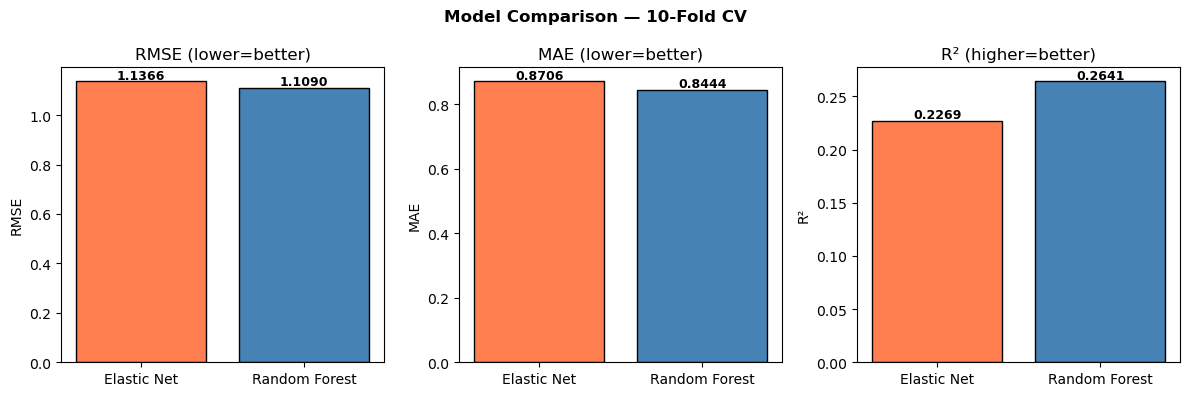

In [25]:
summary = pd.DataFrame({
    'Model':     ['Elastic Net', 'Random Forest'],
    'RMSE Mean': [elastic_rmse.mean(), forest_rmse.mean()],
    'RMSE Std':  [elastic_rmse.std(),  forest_rmse.std()],
    'MAE Mean':  [elastic_mae.mean(),  forest_mae.mean()],
    'MAE Std':   [elastic_mae.std(),   forest_mae.std()],
    'R² Mean':   [elastic_r2.mean(),   forest_r2.mean()],
    'R² Std':    [elastic_r2.std(),    forest_r2.std()],
}).round(4)

display(summary)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
metrics = [
    ('RMSE Mean', 'RMSE', True),
    ('MAE Mean',  'MAE',  True),
    ('R² Mean',   'R²',   False),
]
for ax, (col, label, lower_better) in zip(axes, metrics):
    vals = summary[col].values
    bars = ax.bar(summary['Model'], vals, color=['coral', 'steelblue'], edgecolor='k')
    ax.set_title(label + (' (lower=better)' if lower_better else ' (higher=better)'))
    ax.set_ylabel(label)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + max(vals)*0.01,
                f'{v:.4f}', ha='center', fontweight='bold', fontsize=9)
plt.suptitle('Model Comparison — 10-Fold CV', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Error Analysis

### 5.1 Extracting Outliers

Extracting the 20 movies with the largest prediction errors from cross_val_predict on the best model (Random Forest): 10 largest overpredictions and 10 largest underpredictions.

In [26]:
def count_genres(df_out):
    counts = {}
    for genres in df_out['genres'].dropna():
        try:
            parsed = ast.literal_eval(str(genres))
            items = parsed if isinstance(parsed, list) else str(genres).split(',')
        except:
            items = str(genres).split(',')
        for g in items:
            g = str(g).replace('[','').replace(']','').replace("'",'').replace('"','').strip()
            if g:
                counts[g] = counts.get(g, 0) + 1
    return pd.Series(counts).sort_values(ascending=False)


print('Running cross_val_predict — Random Forest...')
y_pred_cv = cross_val_predict(best_rf_pipe, X, y, cv=kf, n_jobs=-1)
errors = y_pred_cv - y

df_errors = df.loc[X.index, ['tconst', 'primaryTitle', 'startYear', 'genres', 'averageRating']].copy()
df_errors['true_rating'] = y.values
df_errors['pred_rating'] = y_pred_cv.round(2)
df_errors['error']       = errors.round(2)
df_errors['abs_error']   = np.abs(errors).round(2)

outliers_over  = df_errors.nlargest(10,  'error').copy()
outliers_under = df_errors.nsmallest(10, 'error').copy()
all_outliers   = pd.concat([outliers_over, outliers_under])

print('\n=== 10 Overprediction ===')
display(outliers_over[['primaryTitle', 'true_rating', 'pred_rating', 'error', 'startYear', 'genres']])

print('\n=== 10 Underprediction ===')
display(outliers_under[['primaryTitle', 'true_rating', 'pred_rating', 'error', 'startYear', 'genres']])

all_outliers['error_type'] = np.where(all_outliers['error'] > 0, 'Overprediction', 'Underprediction')
print(f'\n✅ {len(all_outliers)} outliers extracted')

Running cross_val_predict — Random Forest...

=== 10 Overprediction ===


,primaryTitle,true_rating,pred_rating,error,startYear,genres
12464,Justin Bieber: Always Believing,1.0,7.18,6.18,2012.0,"Documentary,Music"
133563,Horseplay: The History of Horse Riding,1.0,7.18,6.18,2021.0,"Animation,Documentary"
16815,Kurz,1.2,7.20,6.00,2023.0,Documentary
52582,Rape of the Soul,1.7,7.69,5.99,2006.0,"['Documentary', 'History']"
52638,Ramo Trip,1.4,7.23,5.83,2012.0,['Documentary']
72010,Tribalism Is Killing Us,1.3,7.09,5.79,2019.0,['Documentary']
37806,Obama in NC: The Path to History,1.5,7.28,5.78,2010.0,['Documentary']
10554,Jasenovac: Istina,1.4,7.16,5.76,2016.0,"Documentary,History,Mystery"
104680,Brush with Life: The Art of Being Edward Biberman,1.5,7.17,5.67,2007.0,['Documentary']
12021,Justin Bieber's Believe,1.6,7.26,5.66,2013.0,"Documentary,Music"



=== 10 Underprediction ===


,primaryTitle,true_rating,pred_rating,error,startYear,genres
106898,Bukunja Tekunja Mitti: The Cannibals,9.1,4.35,-4.75,2012.0,"['Action', 'Horror']"
57344,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.37,-4.73,2011.0,"Horror,Thriller"
78652,Ungleich,9.1,4.41,-4.69,2013.0,"['Fantasy', 'Horror']"
131379,Halloween Deluxe,9.1,4.44,-4.66,2019.0,Horror
36522,Oscuro by Rene Potter,8.6,4.04,-4.56,2016.0,['Horror']
38958,Of Sound Mind,9.6,5.21,-4.39,2015.0,"['Romance', 'Thriller']"
126114,Hasruin,9.6,5.25,-4.35,2020.0,"Comedy,Drama,Thriller"
1119,Ice Nine Kills Presents: Welcome to Horrorwood,8.4,4.08,-4.32,2024.0,Horror
43454,Puli Vachindi Meka Chachindi,9.5,5.18,-4.32,2021.0,Thriller
9295,Justicia Implacable,9.5,5.20,-4.30,2023.0,"Action,Drama,Horror"



✅ 20 outliers extracted


In [27]:
print('=== Genres in Overprediction ===')
display(count_genres(outliers_over))

print('\n=== Genres in Underprediction ===')
display(count_genres(outliers_under))

print('=== True vs Predicted by error type ===')
display(all_outliers.groupby('error_type')[['true_rating', 'pred_rating']].mean().round(2))

=== Genres in Overprediction ===


Documentary    10
Music           2
History         2
Animation       1
Mystery         1
dtype: int64


=== Genres in Underprediction ===


Horror      7
Thriller    4
Action      2
Drama       2
Fantasy     1
Romance     1
Comedy      1
dtype: int64

=== True vs Predicted by error type ===


,true_rating,pred_rating
error_type,,
Overprediction,1.36,7.24
Underprediction,9.16,4.65


### 5.2 Qualitative Analysis

Analysis of the 20 outliers - 5 specific movies with detailed explanation, and identification of common patterns across all outliers.

=== התפלגות שנים ===

Overprediction:
count      10.0
mean     2013.9
std         5.7
min      2006.0
25%      2010.5
50%      2012.5
75%      2018.2
max      2023.0
Name: startYear, dtype: float64

Underprediction:
count      10.0
mean     2017.4
std         4.6
min      2011.0
25%      2013.5
50%      2017.5
75%      2020.8
max      2024.0
Name: startYear, dtype: float64


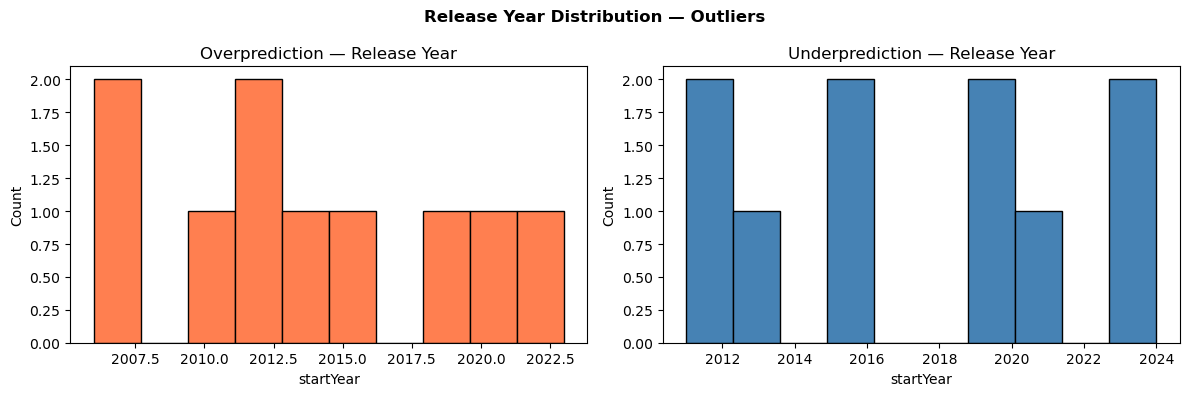


=== Runtime (runtimeMinutes) ===
Overprediction  — Mean: 94.5, Median: 90.0
Underprediction — Mean: 96.5, Median: 84.5


In [28]:
print("=== התפלגות שנים ===")
print("\nOverprediction:")
print(outliers_over['startYear'].describe().round(1))
print("\nUnderprediction:")
print(outliers_under['startYear'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(outliers_over['startYear'].dropna(), bins=10, color='coral', edgecolor='k')
axes[0].set_title('Overprediction — Release Year')
axes[0].set_xlabel('startYear')
axes[0].set_ylabel('Count')

axes[1].hist(outliers_under['startYear'].dropna(), bins=10, color='steelblue', edgecolor='k')
axes[1].set_title('Underprediction — Release Year')
axes[1].set_xlabel('startYear')
axes[1].set_ylabel('Count')

plt.suptitle('Release Year Distribution — Outliers', fontweight='bold')
plt.tight_layout()
plt.show()

runtime_over  = df.loc[outliers_over.index,  'runtimeMinutes']
runtime_under = df.loc[outliers_under.index, 'runtimeMinutes']

print("\n=== Runtime (runtimeMinutes) ===")
print(f"Overprediction  — Mean: {runtime_over.mean():.1f}, Median: {runtime_over.median():.1f}")
print(f"Underprediction — Mean: {runtime_under.mean():.1f}, Median: {runtime_under.median():.1f}")

### 5.3 Model Comparison - Outlier Overlap

Comparing the 20 outliers of both models. How many overlap? When one model fails, does the other succeed?

Running cross_val_predict — Elastic Net...
Running cross_val_predict — Random Forest...
Outliers EN:  20
Outliers RF:  20
Overlap:      11 / 20  (55.0%)

=== Shared outliers ===


,primaryTitle,true_rating,pred_en,pred_rf,error_en,error_rf,genres
6458,Justicia Implacable,9.5,5.07,5.20,-4.43,-4.30,"Action,Drama,Horror"
8633,Justin Bieber: Always Believing,1.0,6.97,7.18,5.97,6.18,"Documentary,Music"
12414,Kurz,1.2,7.04,7.20,5.84,6.00,Documentary
30164,Obama in NC: The Path to History,1.5,7.40,7.28,5.90,5.78,['Documentary']
43217,Rape of the Soul,1.7,7.77,7.69,6.07,5.99,"['Documentary', 'History']"
43273,Ramo Trip,1.4,7.42,7.23,6.02,5.83,['Documentary']
47979,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.61,4.37,-4.49,-4.73,"Horror,Thriller"
60471,Tribalism Is Killing Us,1.3,7.29,7.09,5.99,5.79,['Documentary']
66984,Ungleich,9.1,4.86,4.41,-4.24,-4.69,"['Fantasy', 'Horror']"
88952,Bukunja Tekunja Mitti: The Cannibals,9.1,4.37,4.35,-4.73,-4.75,"['Action', 'Horror']"



=== Unique to EN only (9 movies) ===


,primaryTitle,true_rating,pred_en,pred_rf,error_en,error_rf,genres
4190,Idaho,1.9,7.58,6.92,5.68,5.02,"Adventure,Drama,Western"
27993,Neko,9.2,4.71,5.69,-4.49,-3.51,"['Action', 'Adventure', 'Thriller']"
58897,Akkada Varu Ikkada Unnaru,9.1,4.91,5.62,-4.19,-3.48,['Horror']
72305,Zwischen Glück und Krone,1.2,7.48,6.38,6.28,5.18,['Documentary']
72581,Zen Comedy,9.8,5.27,6.07,-4.53,-3.73,['Comedy']
75094,Zuena,10.0,5.66,6.03,-4.34,-3.97,['Drama']
81148,At the Back of the Screen,1.5,8.42,7.11,6.92,5.61,"Documentary,Drama"
86923,Borderline Forever,9.7,5.25,5.89,-4.45,-3.81,"['Adventure', 'Comedy', 'Fantasy']"
104047,Hantu Nan Sempit,8.7,4.45,4.65,-4.25,-4.05,"Action,Comedy,Horror"



=== Unique to RF only (9 movies) ===


,primaryTitle,true_rating,pred_en,pred_rf,error_en,error_rf,genres
756,Ice Nine Kills Presents: Welcome to Horrorwood,8.4,4.63,4.08,-3.77,-4.32,Horror
7332,Jasenovac: Istina,1.4,6.89,7.16,5.49,5.76,"Documentary,History,Mystery"
8334,Justin Bieber's Believe,1.6,7.21,7.26,5.61,5.66,"Documentary,Music"
29350,Oscuro by Rene Potter,8.6,4.72,4.04,-3.88,-4.56,['Horror']
30915,Of Sound Mind,9.6,5.48,5.21,-4.12,-4.39,"['Romance', 'Thriller']"
34089,Puli Vachindi Meka Chachindi,9.5,5.50,5.18,-4.00,-4.32,Thriller
87292,Brush with Life: The Art of Being Edward Biberman,1.5,7.09,7.17,5.59,5.67,['Documentary']
107790,Hasruin,9.6,5.44,5.25,-4.16,-4.35,"Comedy,Drama,Thriller"
113055,Halloween Deluxe,9.1,5.97,4.44,-3.13,-4.66,Horror



=== When EN fails, how does RF do? ===
EN mean abs error: 5.014
RF mean abs error: 4.262

=== When RF fails, how does EN do? ===
RF mean abs error: 4.854
EN mean abs error: 4.417


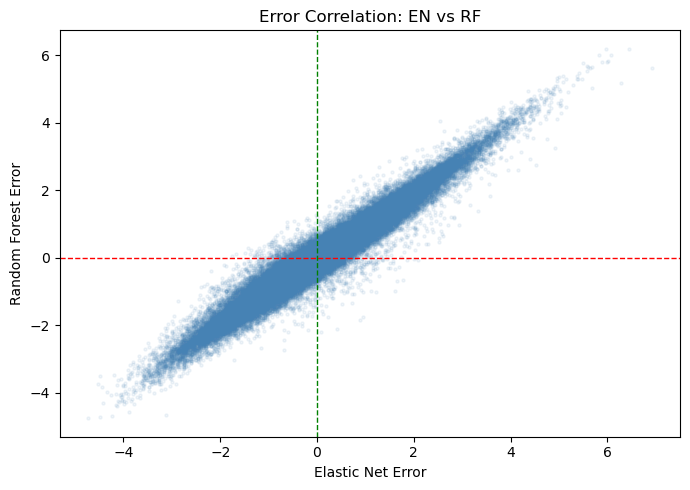

In [29]:
print('Running cross_val_predict — Elastic Net...')
y_pred_en = cross_val_predict(best_elastic_pipe, X, y, cv=kf, n_jobs=-1)
print('Running cross_val_predict — Random Forest...')
y_pred_rf = cross_val_predict(best_rf_pipe, X, y, cv=kf, n_jobs=-1)

errors_en = y_pred_en - y.values
errors_rf = y_pred_rf - y.values

df_compare = pd.DataFrame({
    'primaryTitle': df.loc[X.index, 'primaryTitle'].values,
    'tconst':       df.loc[X.index, 'tconst'].values,
    'true_rating':  y.values,
    'pred_en':      y_pred_en.round(2),
    'pred_rf':      y_pred_rf.round(2),
    'error_en':     errors_en.round(2),
    'error_rf':     errors_rf.round(2),
    'abs_error_en': np.abs(errors_en).round(2),
    'abs_error_rf': np.abs(errors_rf).round(2),
    'genres':       df.loc[X.index, 'genres'].values,
    'startYear':    df.loc[X.index, 'startYear'].values,
})

over_en  = set(df_compare.nlargest(10,  'error_en')['tconst'])
under_en = set(df_compare.nsmallest(10, 'error_en')['tconst'])
over_rf  = set(df_compare.nlargest(10,  'error_rf')['tconst'])
under_rf = set(df_compare.nsmallest(10, 'error_rf')['tconst'])

all_en  = over_en  | under_en
all_rf  = over_rf  | under_rf
overlap = all_en & all_rf
only_en = all_en - all_rf
only_rf = all_rf - all_en

print(f'Outliers EN:  {len(all_en)}')
print(f'Outliers RF:  {len(all_rf)}')
print(f'Overlap:      {len(overlap)} / 20  ({len(overlap)/20*100:.1f}%)')

print('\n=== Shared outliers ===')
display(df_compare[df_compare['tconst'].isin(overlap)][[
    'primaryTitle', 'true_rating', 'pred_en', 'pred_rf', 'error_en', 'error_rf', 'genres'
]])

print(f'\n=== Unique to EN only ({len(only_en)} movies) ===')
display(df_compare[df_compare['tconst'].isin(only_en)][[
    'primaryTitle', 'true_rating', 'pred_en', 'pred_rf', 'error_en', 'error_rf', 'genres'
]])

print(f'\n=== Unique to RF only ({len(only_rf)} movies) ===')
display(df_compare[df_compare['tconst'].isin(only_rf)][[
    'primaryTitle', 'true_rating', 'pred_en', 'pred_rf', 'error_en', 'error_rf', 'genres'
]])

only_en_df = df_compare[df_compare['tconst'].isin(only_en)]
only_rf_df = df_compare[df_compare['tconst'].isin(only_rf)]

if len(only_en_df) > 0:
    print(f'\n=== When EN fails, how does RF do? ===')
    print(f'EN mean abs error: {only_en_df["abs_error_en"].mean():.3f}')
    print(f'RF mean abs error: {only_en_df["abs_error_rf"].mean():.3f}')

if len(only_rf_df) > 0:
    print(f'\n=== When RF fails, how does EN do? ===')
    print(f'RF mean abs error: {only_rf_df["abs_error_rf"].mean():.3f}')
    print(f'EN mean abs error: {only_rf_df["abs_error_en"].mean():.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(errors_en, errors_rf, alpha=0.08, s=5, color='steelblue')
ax.axhline(0, color='red',   lw=1, ls='--')
ax.axvline(0, color='green', lw=1, ls='--')
ax.set_xlabel('Elastic Net Error')
ax.set_ylabel('Random Forest Error')
ax.set_title('Error Correlation: EN vs RF')
plt.tight_layout()
plt.show()

In [30]:
# Error types unique to each model
print('\n=== Error Types Unique to Each Model ===')

print('\n--- Unique to EN ---')
print(f'Overpredictions:  {(only_en_df["error_en"] > 0).sum()}')
print(f'Underpredictions: {(only_en_df["error_en"] < 0).sum()}')

print('\n--- Unique to RF ---')
print(f'Overpredictions:  {(only_rf_df["error_rf"] > 0).sum()}')
print(f'Underpredictions: {(only_rf_df["error_rf"] < 0).sum()}')


=== Error Types Unique to Each Model ===

--- Unique to EN ---
Overpredictions:  3
Underpredictions: 6

--- Unique to RF ---
Overpredictions:  3
Underpredictions: 6


In [31]:
shared_df = df_compare[df_compare['tconst'].isin(overlap)].copy()
unique_df = df_compare[df_compare['tconst'].isin(only_en | only_rf)].copy()

# Shared outliers
shared_over = shared_df[
    (shared_df['error_en'] > 0) | (shared_df['error_rf'] > 0)
].copy()

shared_under = shared_df[
    (shared_df['error_en'] < 0) | (shared_df['error_rf'] < 0)
].copy()

# Unique outliers
unique_over = unique_df[
    (unique_df['error_en'] > 0) | (unique_df['error_rf'] > 0)
].copy()

unique_under = unique_df[
    (unique_df['error_en'] < 0) | (unique_df['error_rf'] < 0)
].copy()

width = 0.35

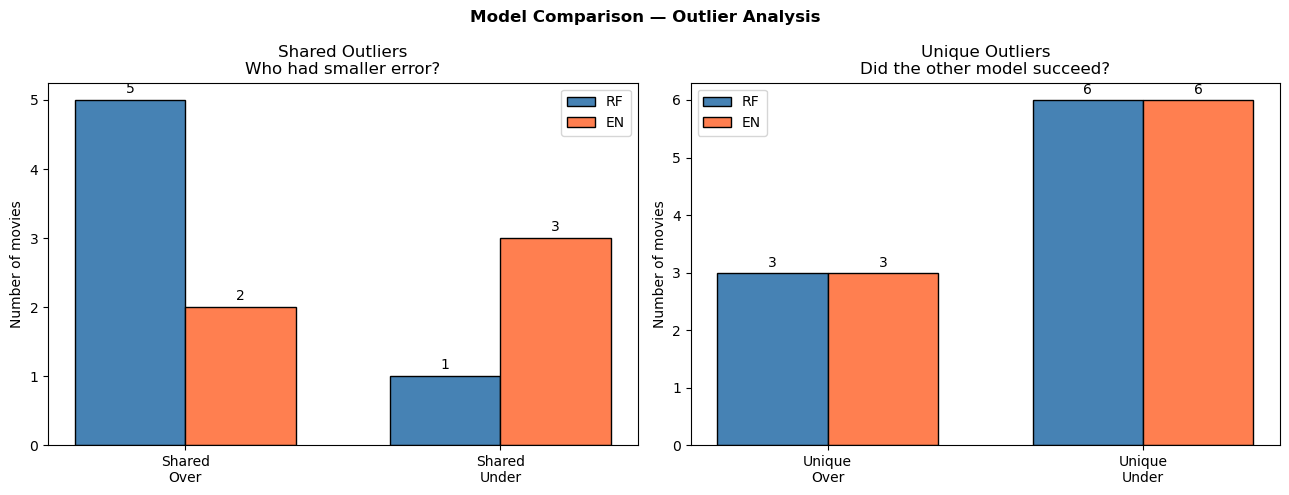

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

#  גרף 1: Shared — מי טעה פחות? 
shared_cats = ['Shared\nOver', 'Shared\nUnder']
shared_dfs  = [shared_over, shared_under]

rf_shared = [(d['abs_error_rf'] < d['abs_error_en']).sum() for d in shared_dfs]
en_shared = [(d['abs_error_en'] < d['abs_error_rf']).sum() for d in shared_dfs]

x1 = np.arange(len(shared_cats))
b1 = axes[0].bar(x1 - width/2, rf_shared, width, label='RF', color='steelblue', edgecolor='k')
b2 = axes[0].bar(x1 + width/2, en_shared, width, label='EN', color='coral',     edgecolor='k')
for bar in list(b1) + list(b2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)), ha='center', fontsize=10)
axes[0].set_xticks(x1)
axes[0].set_xticklabels(shared_cats)
axes[0].set_ylabel('Number of movies')
axes[0].set_title('Shared Outliers\nWho had smaller error?')
axes[0].legend()

#  גרף 2: Unique — האם המודל השני הצליח? 
unique_cats = ['Unique\nOver', 'Unique\nUnder']
unique_dfs  = [unique_over, unique_under]

rf_unique = [(d['abs_error_rf'] < d['abs_error_en']).sum() for d in unique_dfs]
en_unique = [(d['abs_error_en'] < d['abs_error_rf']).sum() for d in unique_dfs]

x2 = np.arange(len(unique_cats))
b3 = axes[1].bar(x2 - width/2, rf_unique, width, label='RF', color='steelblue', edgecolor='k')
b4 = axes[1].bar(x2 + width/2, en_unique, width, label='EN', color='coral',     edgecolor='k')
for bar in list(b3) + list(b4):
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.1, str(int(h)), ha='center', fontsize=10)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(unique_cats)
axes[1].set_ylabel('Number of movies')
axes[1].set_title('Unique Outliers\nDid the other model succeed?')
axes[1].legend()

plt.suptitle('Model Comparison — Outlier Analysis', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Fairness Analysis

Examining whether the model performs equally well across different slices of the data.
Two slices were chosen: by genre and by release decade.

### 6.1,6.2 Slice 1 - By Genre (top 5 most common genres)

Computing RMSE and MAE for the 5 most common genres. Each movie can appear in more than one genre.

5 הז'אנרים הנפוצים ביותר: ['Drama', 'Comedy', 'Romance', 'Action', 'Documentary']
=== Fairness by Genre ===


,Genre,N,RMSE,MAE
0,Drama,58460,1.0488,0.7978
1,Comedy,33316,1.1208,0.8591
2,Romance,15693,1.0117,0.7684
3,Action,13987,1.2024,0.9319
4,Documentary,13014,0.9918,0.7255


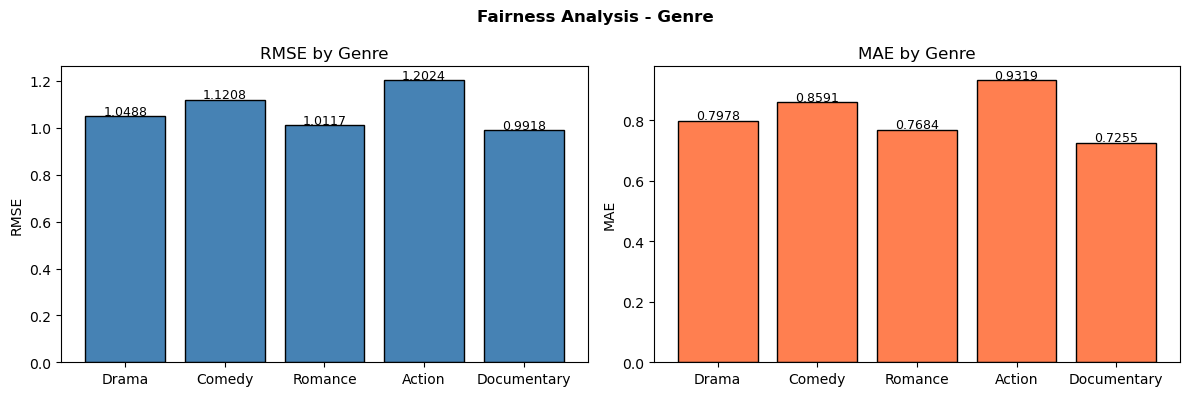

In [33]:
# תחזיות CV של RF
y_pred_rf = cross_val_predict(best_rf_pipe, X, y, cv=kf, n_jobs=-1)

df_fairness = df.loc[X.index].copy()
df_fairness['y_true'] = y.values
df_fairness['y_pred'] = y_pred_rf

def parse_genres_simple(x):
    if pd.isna(x):
        return []
    x_str = str(x).strip()
    try:
        result = ast.literal_eval(x_str)
        if isinstance(result, list):
            return [str(g).strip() for g in result]
    except:
        pass
    x_str = x_str.replace('[','').replace(']','').replace("'",'').replace('"','')
    return [g.strip() for g in x_str.split(',') if g.strip()]

df_fairness['genres_list'] = df.loc[X.index, 'genres'].apply(parse_genres_simple)

all_genres_list = [genre for genres in df_fairness['genres_list'] for genre in genres]
genre_counts = Counter(all_genres_list)
TOP_GENRES_FAIR = [genre for genre, count in genre_counts.most_common(5)]
print('5 הז\'אנרים הנפוצים ביותר:', TOP_GENRES_FAIR)

genre_results = []
for genre in TOP_GENRES_FAIR:
    mask = df_fairness['genres_list'].apply(lambda x: genre in x)
    subset = df_fairness[mask]
    if len(subset) == 0:
        continue
    rmse = np.sqrt(mean_squared_error(subset['y_true'], subset['y_pred']))
    mae  = mean_absolute_error(subset['y_true'], subset['y_pred'])
    genre_results.append({'Genre': genre, 'N': len(subset),
                          'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

df_genre = pd.DataFrame(genre_results)
print('=== Fairness by Genre ===')
display(df_genre)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df_genre['Genre'], df_genre['RMSE'], color='steelblue', edgecolor='k')
axes[0].set_title('RMSE by Genre')
axes[0].set_ylabel('RMSE')
for i, v in enumerate(df_genre['RMSE']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

axes[1].bar(df_genre['Genre'], df_genre['MAE'], color='coral', edgecolor='k')
axes[1].set_title('MAE by Genre')
axes[1].set_ylabel('MAE')
for i, v in enumerate(df_genre['MAE']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.suptitle('Fairness Analysis - Genre', fontweight='bold')
plt.tight_layout()
plt.show()

### 6.1,6.2 Slice 2 - By Release Decade

Computing RMSE and MAE by decade of release (at least 3 decades).

=== Fairness by Decade ===


,Decade,N,RMSE,MAE
0,1910,171,0.8441,0.6371
1,1920,785,0.9920,0.7371
2,1930,3121,0.8000,0.5918
3,1940,3292,0.7949,0.5971
4,1950,4602,0.8671,0.6643
5,1960,6208,0.9859,0.7778
6,1970,7969,1.0159,0.7982
7,1980,9631,1.0477,0.8190
8,1990,10213,1.0611,0.8274
9,2000,17555,1.1387,0.8692


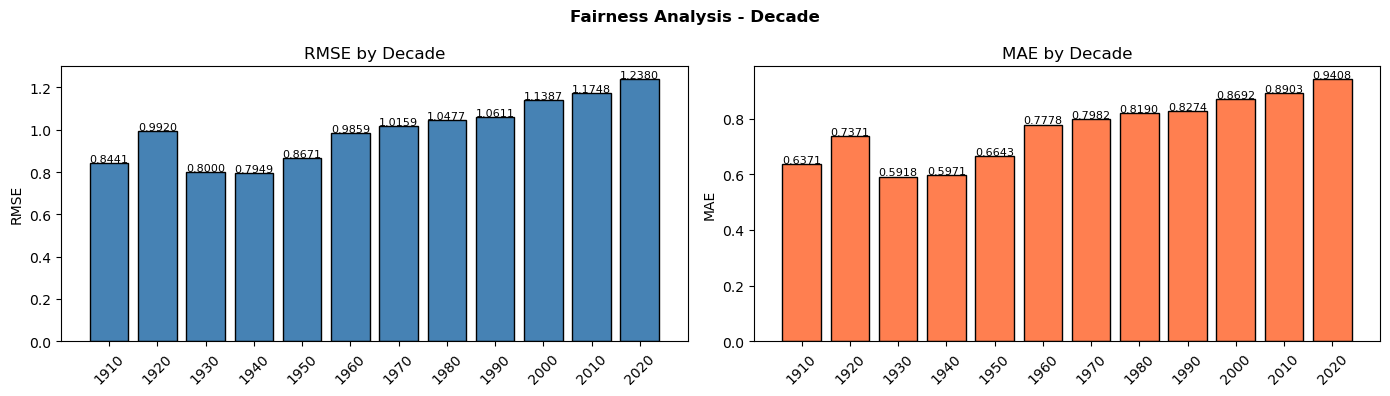

In [34]:
df_fairness['decade'] = (df_fairness['startYear'] // 10) * 10

decade_results = []
for decade in sorted(df_fairness['decade'].dropna().unique()):
    subset = df_fairness[df_fairness['decade'] == decade]
    if len(subset) < 50:
        continue
    rmse = np.sqrt(mean_squared_error(subset['y_true'], subset['y_pred']))
    mae  = mean_absolute_error(subset['y_true'], subset['y_pred'])
    decade_results.append({'Decade': int(decade), 'N': len(subset),
                           'RMSE': round(rmse, 4), 'MAE': round(mae, 4)})

df_decade = pd.DataFrame(decade_results)
print('=== Fairness by Decade ===')
display(df_decade)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(df_decade['Decade'].astype(str), df_decade['RMSE'], color='steelblue', edgecolor='k')
axes[0].set_title('RMSE by Decade')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_decade['RMSE']):
    axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

axes[1].bar(df_decade['Decade'].astype(str), df_decade['MAE'], color='coral', edgecolor='k')
axes[1].set_title('MAE by Decade')
axes[1].set_ylabel('MAE')
axes[1].tick_params(axis='x', rotation=45)
for i, v in enumerate(df_decade['MAE']):
    axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Fairness Analysis - Decade', fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

Identifying the top 5 most important features for each model:
- **Elastic Net** - based on standardized coefficients (size and direction)
- **Random Forest** - based on permutation importance

Comparing both models: where do they agree and where do they differ?

In [35]:
feature_names_en = best_elastic_pipe.named_steps['preprocessor'].get_feature_names_out()
feature_names_rf = best_rf_pipe.named_steps['preprocessor'].get_feature_names_out()

Elastic Net coefficients: 16
Elastic Net feature names: 16
=== Elastic Net — Top 5 Features ===


,Feature,Coefficient,Abs_Coefficient,Direction
12,binary__is_documentary,0.445787,0.445787,Positive
1,nan__runtimeMinutes,0.254835,0.254835,Positive
11,binary__is_horror,-0.243249,0.243249,Negative
6,binary__is_drama,0.158054,0.158054,Positive
8,binary__is_action,-0.128529,0.128529,Negative


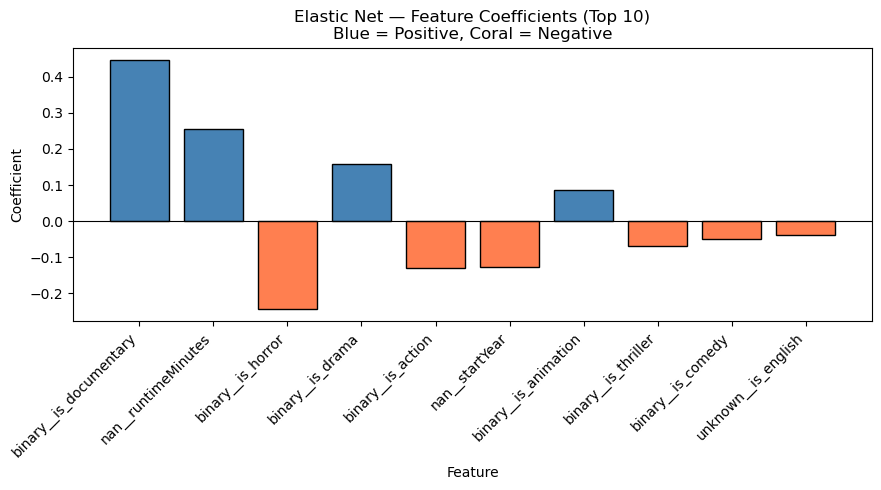

In [36]:
# 7.1 Elastic Net — מקדמים סטנדרטיים

en_model = best_elastic_pipe.named_steps['model']
en_coefs = en_model.coef_

print("Elastic Net coefficients:", len(en_coefs))
print("Elastic Net feature names:", len(feature_names_en))
assert len(en_coefs) == len(feature_names_en), "Mismatch between Elastic Net coefficients and feature names"

df_en = pd.DataFrame({'Feature': feature_names_en, 'Coefficient': en_coefs})
df_en['Abs_Coefficient'] = df_en['Coefficient'].abs()
df_en['Direction'] = df_en['Coefficient'].apply(lambda x: 'Positive' if x > 0 else 'Negative')
df_en = df_en.sort_values('Abs_Coefficient', ascending=False)

print('=== Elastic Net — Top 5 Features ===')
display(df_en.head(5))

colors_en = ['steelblue' if c > 0 else 'coral' for c in df_en.head(10)['Coefficient']]

plt.figure(figsize=(9, 5))
plt.bar(df_en.head(10)['Feature'], df_en.head(10)['Coefficient'], color=colors_en, edgecolor='k')
plt.axhline(0, color='black', lw=0.8)
plt.title('Elastic Net — Feature Coefficients (Top 10)\nBlue = Positive, Coral = Negative')
plt.xlabel('Feature')
plt.ylabel('Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Running permutation importance — Random Forest...
Permutation importance: 16
Original X columns: 16
=== Random Forest — Top 5 Features (Permutation Importance) ===


,Feature,Importance,Std
10,is_documentary,0.134026,0.001184
1,runtimeMinutes,0.094138,0.000966
0,startYear,0.065185,0.001164
9,is_horror,0.064842,0.000992
4,is_drama,0.037233,0.000558


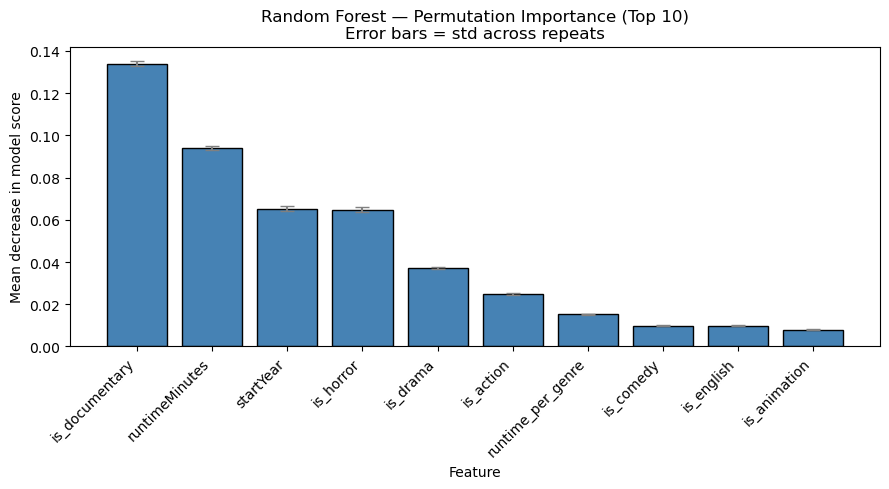

In [37]:
# 7.2 Random Forest — Permutation Importance

print('Running permutation importance — Random Forest...')

perm_rf = permutation_importance(
    estimator=best_rf_pipe,
    X=X,
    y=y,
    n_repeats=10,
    random_state=42,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print("Permutation importance:", len(perm_rf.importances_mean))
print("Original X columns:", len(X.columns))
assert len(perm_rf.importances_mean) == len(X.columns), "Mismatch between permutation importance and X columns"

df_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm_rf.importances_mean,
    'Std': perm_rf.importances_std
}).sort_values('Importance', ascending=False)

print('=== Random Forest — Top 5 Features (Permutation Importance) ===')
display(df_rf.head(5))

plt.figure(figsize=(9, 5))
plt.bar(df_rf.head(10)['Feature'], df_rf.head(10)['Importance'],
        yerr=df_rf.head(10)['Std'], color='steelblue', edgecolor='k',
        capsize=5, error_kw={'elinewidth': 1.5, 'ecolor': 'gray'})
plt.title('Random Forest — Permutation Importance (Top 10)\nError bars = std across repeats')
plt.xlabel('Feature')
plt.ylabel('Mean decrease in model score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Computing SHAP values — Random Forest...
SHAP transformed features: 16
SHAP feature names: 16


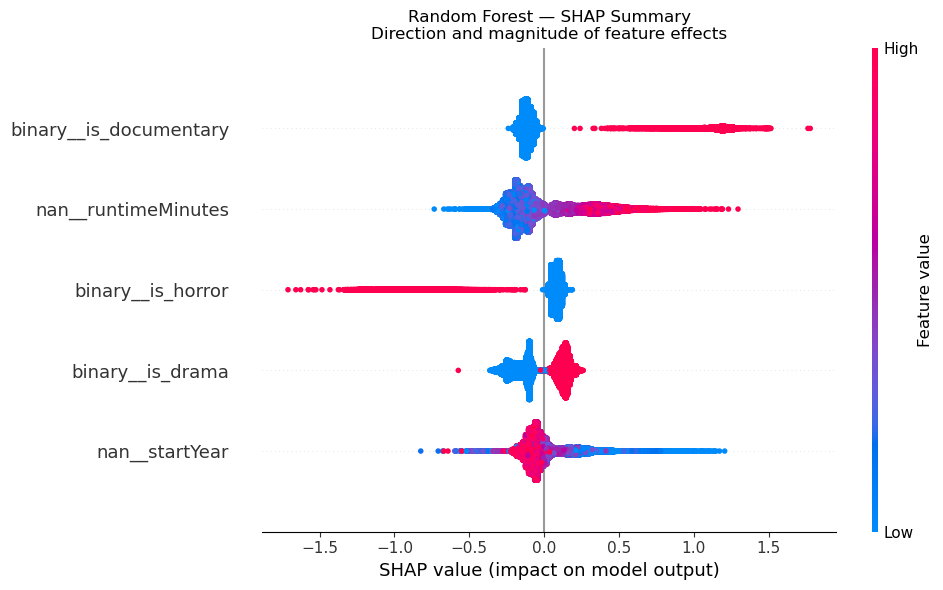

In [38]:
# 7.3 Random Forest — SHAP

print('Computing SHAP values — Random Forest...')

preprocessor_rf = best_rf_pipe.named_steps['preprocessor']
rf_model = best_rf_pipe.named_steps['model']
X_transformed = preprocessor_rf.transform(X)

print("SHAP transformed features:", X_transformed.shape[1])
print("SHAP feature names:", len(feature_names_rf))
assert X_transformed.shape[1] == len(feature_names_rf), "Mismatch between SHAP transformed data and feature names"

explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_transformed)

shap.summary_plot(
    shap_values,
    X_transformed,
    feature_names=feature_names_rf,
    max_display=5,
    plot_size=(10, 6),
    show=False
)

plt.title('Random Forest — SHAP Summary\nDirection and magnitude of feature effects')
plt.tight_layout()
plt.show()

In [39]:
# 7.4 השוואה בין המודלים
df_en['Feature_clean'] = df_en['Feature'].str.replace(r'^.*__', '', regex=True)

top5_en = set(df_en.head(5)['Feature_clean'])
top5_rf = set(df_rf.head(5)['Feature'])
overlap = top5_en & top5_rf

print('\n=== Comparison Between Models ===')
print(f'Top 5 Elastic Net:    {top5_en}')
print(f'Top 5 Random Forest:  {top5_rf}')
print(f'Overlap: {overlap} ({len(overlap)}/5)')


=== Comparison Between Models ===
Top 5 Elastic Net:    {'is_documentary', 'is_action', 'is_horror', 'runtimeMinutes', 'is_drama'}
Top 5 Random Forest:  {'is_documentary', 'startYear', 'is_horror', 'runtimeMinutes', 'is_drama'}
Overlap: {'is_documentary', 'runtimeMinutes', 'is_drama', 'is_horror'} (4/5)


## 10. Saving the Model

Saving the best model (Elastic Net) as model.pkl for use at test time.

In [40]:
joblib.dump(best_elastic_pipe, 'model.pkl')
print('Saved: model.pkl (Elastic Net)')

loaded_model = joblib.load('model.pkl')
test_pred = loaded_model.predict(X.head(5))
print('Test predictions:', test_pred.round(2))
print('True values:     ', y.head(5).values)

Saved: model.pkl (Elastic Net)
Test predictions: [6.13 5.92 5.75 7.18 8.04]
True values:      [6.6 6.1 6.1 7.  9.2]
